# 10 — Simulador adaptativo

## Idea principal

En lugar de fijar únicamente un número de escenarios, el
simulador evalúa continuamente la estabilidad estadística
de sus resultados.

El proceso comienza con una cantidad inicial de escenarios.

Después de cada lote se calcula el error estándar de la media.

Si el error todavía es superior al objetivo:

    generar más escenarios

Si el error alcanza el objetivo:

    detener la simulación

De esta manera, el esfuerzo computacional se adapta a la
estabilidad observada en los resultados.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from src.simulation.adaptive import (
    AdaptiveConfig,
    calculate_standard_error,
    should_continue,
)

In [4]:
simulation_data = pd.read_csv(
    PROJECT_ROOT
    / "results"
    / "tables"
    / "sequential_simulation.csv"
)

final_values = (
    simulation_data["final_value"]
    .to_numpy()
)

print(
    f"Escenarios disponibles: "
    f"{len(final_values):,}"
)

Escenarios disponibles: 1,000


In [5]:
adaptive_config = AdaptiveConfig(
    initial_scenarios=100,
    batch_size=100,
    max_scenarios=len(final_values),
    target_standard_error=0.05,
)

print(
    adaptive_config
)

AdaptiveConfig(initial_scenarios=100, batch_size=100, max_scenarios=1000, target_standard_error=0.05, confidence_level=0.95)


In [6]:
observed_values = []

history = []

current_index = 0

while current_index < len(final_values):

    next_index = min(
        current_index
        + adaptive_config.batch_size,
        len(final_values),
    )

    batch = final_values[
        current_index:next_index
    ]

    observed_values.extend(
        batch
    )

    current_index = next_index

    values_array = np.asarray(
        observed_values,
        dtype=np.float64,
    )

    standard_error = (
        calculate_standard_error(
            values_array
        )
    )

    history.append(
        {
            "scenarios": len(values_array),
            "standard_error": standard_error,
            "mean": float(
                np.mean(values_array)
            ),
        }
    )

    if not should_continue(
        standard_error=standard_error,
        target_standard_error=(
            adaptive_config.target_standard_error
        ),
        number_of_scenarios=len(
            values_array
        ),
        max_scenarios=(
            adaptive_config.max_scenarios
        ),
    ):
        break

In [7]:
adaptive_history = pd.DataFrame(
    history
)

adaptive_history

,scenarios,standard_error,mean
0,100,2.243307,115.849075
1,200,1.483304,113.088719
2,300,1.198286,113.032087
3,400,1.003517,111.880270
4,500,0.870238,112.041457
5,600,0.777625,111.984971
6,700,0.728595,112.647052
7,800,0.680309,112.755554
8,900,0.647938,112.889794
9,1000,0.616475,113.061866


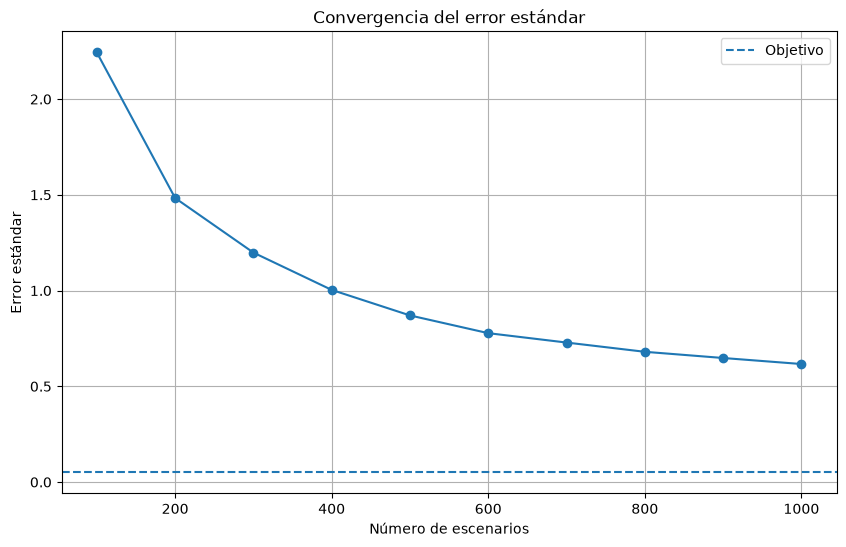

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(
    adaptive_history["scenarios"],
    adaptive_history["standard_error"],
    marker="o",
)

plt.axhline(
    adaptive_config.target_standard_error,
    linestyle="--",
    label="Objetivo",
)

plt.title(
    "Convergencia del error estándar"
)

plt.xlabel(
    "Número de escenarios"
)

plt.ylabel(
    "Error estándar"
)

plt.legend()

plt.grid(True)

plt.show()

In [9]:
scenarios_used = (
    adaptive_history
    .iloc[-1]["scenarios"]
)

final_standard_error = (
    adaptive_history
    .iloc[-1]["standard_error"]
)

print(
    f"Escenarios utilizados: "
    f"{int(scenarios_used):,}"
)

print(
    f"Error estándar final: "
    f"{final_standard_error:.6f}"
)

print(
    f"Objetivo: "
    f"{adaptive_config.target_standard_error:.6f}"
)

Escenarios utilizados: 1,000
Error estándar final: 0.616475
Objetivo: 0.050000


In [10]:
if (
    final_standard_error
    <= adaptive_config.target_standard_error
):
    print(
        "Criterio alcanzado: "
        "la simulación puede detenerse."
    )
else:
    print(
        "Criterio no alcanzado: "
        "serían necesarios más escenarios."
    )

Criterio no alcanzado: serían necesarios más escenarios.


# Resultado

El experimento demuestra el principio de simulación adaptativa:

El número de escenarios deja de ser únicamente un parámetro
fijado manualmente y puede convertirse en una variable controlada
por la estabilidad estadística observada.

Este mecanismo será utilizado posteriormente como base para
estudiar una estrategia de asignación dinámica de recursos
computacionales.